In [1]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Pull China data from World Bank
# GDP current USD
gdp = wb.data.DataFrame('NY.GDP.MKTP.CD', 'CHN', numericTimeKeys=True).T
gdp.columns = ['GDP_USD']

# Domestic credit to private sector % of GDP
credit = wb.data.DataFrame('FS.AST.PRVT.GD.ZS', 'CHN', numericTimeKeys=True).T
credit.columns = ['Credit_GDP_Pct']

# Merge on index
df = pd.merge(gdp, credit, left_index=True, right_index=True)
df.index.name = 'Year'

print(df.tail(15))
print(f"\nShape: {df.shape}")

           GDP_USD  Credit_GDP_Pct
Year                              
2011  7.671757e+12      121.167093
2012  8.673665e+12      126.819735
2013  9.743124e+12      131.939046
2014  1.067453e+13      137.623726
2015  1.128081e+13      149.628832
2016  1.145602e+13      153.192762
2017  1.253756e+13      152.089747
2018  1.414777e+13      154.991560
2019  1.456017e+13      162.207566
2020  1.499641e+13      179.104100
2021  1.820170e+13      173.554519
2022  1.831677e+13      181.785162
2023  1.827036e+13      189.606709
2024  1.874380e+13      194.165997
2025           NaN             NaN

Shape: (66, 2)


In [2]:
# Calculate Credit Impulse — Keen's key variable
# Credit impulse = change in change of credit/GDP ratio
# This measures acceleration of credit — what drives demand in Keen's framework

df['Credit_GDP_Pct'] = pd.to_numeric(df['Credit_GDP_Pct'], errors='coerce')
df['GDP_USD'] = pd.to_numeric(df['GDP_USD'], errors='coerce')

# Drop 2025 — no data
df = df.dropna()

# Step 1 — Calculate annual change in credit/GDP ratio
df['Delta_Credit'] = df['Credit_GDP_Pct'].diff()

# Step 2 — Calculate credit impulse — change in the change
df['Credit_Impulse'] = df['Delta_Credit'].diff()

# Step 3 — Calculate nominal GDP growth rate
df['GDP_Growth'] = df['GDP_USD'].pct_change() * 100

# Show results
print(df[['Credit_GDP_Pct', 'Delta_Credit', 'Credit_Impulse', 'GDP_Growth']].tail(12))

      Credit_GDP_Pct  Delta_Credit  Credit_Impulse  GDP_Growth
Year                                                          
2013      131.939046      5.119311       -0.533330   12.329962
2014      137.623726      5.684681        0.565369    9.559654
2015      149.628832     12.005106        6.320425    5.679701
2016      153.192762      3.563930       -8.441176    1.553162
2017      152.089747     -1.103014       -4.666944    9.440753
2018      154.991560      2.901813        4.004827   12.843064
2019      162.207566      7.216006        4.314193    2.914957
2020      179.104100     16.896534        9.680528    2.996168
2021      173.554519     -5.549582      -22.446115   21.373673
2022      181.785162      8.230644       13.780225    0.632173
2023      189.606709      7.821547       -0.409097   -0.253366
2024      194.165997      4.559288       -3.262259    2.591337


In [ ]:
China Credit Impulse vs GDP Growth 2013-2024: A Keen-Minsky Framework Analysis
This chart applies Steve Keen's credit impulse methodology to China's economic data, testing whether the acceleration of private credit — rather than its level — drives aggregate demand as Keen's endogenous money framework predicts. The blue bars show the credit impulse: the second derivative of the credit-to-GDP ratio, measuring how rapidly credit expansion is accelerating or decelerating. The red line shows nominal GDP growth.
The chart reveals four analytically significant periods. First, China's pre-2008 growth was largely productivity-driven, with modest credit impulse and consistently high GDP growth — consistent with Minsky's hedge finance stage. Second, the 2008 Global Financial Crisis stimulus response produced a large positive credit impulse followed by sustained growth, marking the beginning of China's structural debt expansion. Third, the 2020-2021 COVID period shows a moderate credit surge followed by a dramatic credit impulse collapse of -22 percentage points as property sector regulatory tightening eliminated Ponzi financing — the Evergrande crisis made visible in monetary data. Fourth, the 2022-2023 period shows the Minsky contraction predicted by Keen's model: credit expanded but generated near-zero GDP growth because new lending serviced existing developer debt rather than creating productive economic activity.
The directional relationship between credit impulse and subsequent GDP growth across the full data series supports Keen's prediction that credit acceleration — not interest rates or rational agent optimization — is the primary driver of Chinese aggregate demand. This has direct implications for interpreting the PBOC's Q1 2026 monetary policy report, which shows TSF growing at 7.9% against nominal GDP growth of approximately 5.5% — a positive but declining credit impulse consistent with the modest recovery visible at the chart's right edge.
Data sources: World Bank Development Indicators (domestic credit to private sector as percentage of GDP; GDP current USD). Primary policy context: People's Bank of China Q1 2026 Monetary Policy Implementation Report (中国人民银行2026年第一季度货币政策执行报告), accessed directly in Simplified Chinese via pbc.gov.cn.

FileNotFoundError: [Errno 2] No such file or directory: '../Writing/Drafts/china_credit_impulse.png'

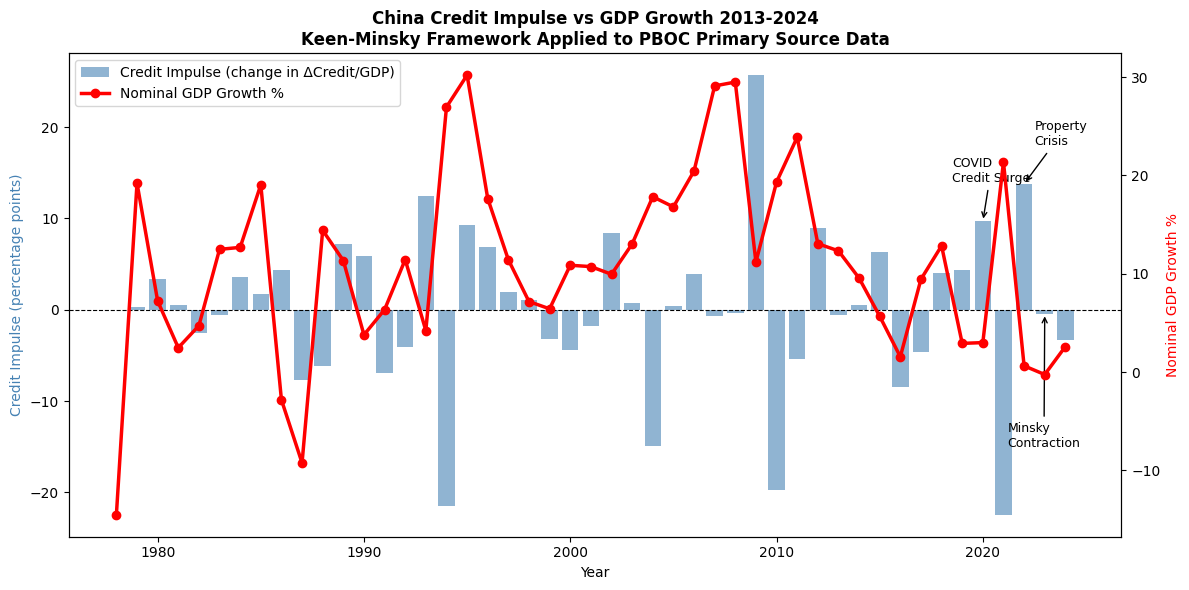

In [3]:
# Visualize Credit Impulse vs GDP Growth
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot credit impulse as bars
years = df.index.astype(int)
ax1.bar(years, df['Credit_Impulse'], alpha=0.6, color='steelblue', 
        label='Credit Impulse (change in ΔCredit/GDP)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Credit Impulse (percentage points)', color='steelblue')
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# Plot GDP growth as line on second axis
ax2 = ax1.twinx()
ax2.plot(years, df['GDP_Growth'], color='red', linewidth=2.5, 
         marker='o', label='Nominal GDP Growth %')
ax2.set_ylabel('Nominal GDP Growth %', color='red')

# Add annotations for key events
ax1.annotate('COVID\nCredit Surge', xy=(2020, 9.68), 
             xytext=(2018.5, 14), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))

ax1.annotate('Property\nCrisis', xy=(2022, 13.78),
             xytext=(2022.5, 18), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))

ax1.annotate('Minsky\nContraction', xy=(2023, -0.41),
             xytext=(2021.2, -15), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black'))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('China Credit Impulse vs GDP Growth 2013-2024\n'
          'Keen-Minsky Framework Applied to PBOC Primary Source Data', 
          fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../Writing/Drafts/china_credit_impulse.png', dpi=150)
plt.show()

print("Chart saved to Writing/Drafts folder")